<h1>Simulation & Risk HW 1</h1>

In [3]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import gaussian_kde
import seaborn as sns
from sklearn.neighbors import KernelDensity

from google.colab import files
uploaded = files.upload()

Saving Analysis_Data.xlsx to Analysis_Data.xlsx


In [4]:
#read in data
projections = pd.read_excel('Analysis_Data.xlsx', header=2, sheet_name='Price Projections')
data = pd.read_excel('Analysis_Data.xlsx', header=2, sheet_name='Drilling Cost')

In [5]:
#limit data to only be from 1990-2006
data = data[(data['Date']>'1990-06-30')&(data['Date']<'2007-06-30')].reset_index(drop=True)

In [6]:
#get average cost in 2006 for starting point
P0 = data.iloc[15, [1, 2, 3]].mean()

In [7]:
#reformatting the data
#pivot data into long format to make the 48 observations
data = pd.melt(data,
                  id_vars=['Date'],
                  value_vars=['Arithmetic Return - Crude Oil', 'Arithmetic Return - Natural Gas', 'Arithmetic Return - Dry Well'],
                  var_name='Well Type',
                  value_name='Change')

#sort by date and well type
data = data.sort_values(by=['Date','Well Type'], ascending=True).reset_index(drop=True)

#get rid of the 'arithmetic return -' substring before the well type
data['Well Type'] = data['Well Type'].str.replace('Arithmetic Return - ', '')

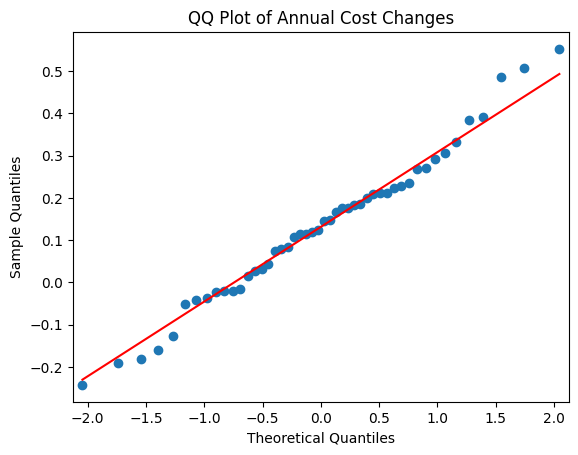

Test Statistic: 0.985319839290827
p-value: 0.8041274885571373


In [8]:
#test for normality
sm.qqplot(data['Change'], line='s')
plt.title("QQ Plot of Annual Cost Changes")
plt.show()

stat, p = shapiro(data['Change'])

print("Test Statistic:", stat)
print("p-value:", p)

In [9]:
#Dr. Hale's code for summarizing the simulation
SEED = 112358
rng = np.random.default_rng(SEED)

def summarize_sim(final_values: np.ndarray, initial_value: float = 1000.0) -> pd.DataFrame:
    """One-row summary: loss probability + 55% and 95% return levels."""
    final_values = np.asarray(final_values, dtype=float)
    returns = final_values / initial_value - 1.0

    loss_prob = float(np.mean(final_values < initial_value))
    q55 = float(np.quantile(returns, 0.55))
    q95 = float(np.quantile(returns, 0.95))

    return pd.DataFrame({
        "Initial Value": [initial_value],
        "Mean Final Value": [float(final_values.mean())],
        "Median Final Value": [float(np.median(final_values))],
        "Prob(Lose Money)": [loss_prob],
        "55% Return Level": [q55],
        "95% Return Level": [q95],
    })

<h2>2006 - 2012 Distribution</h2>

<h4>Normal Distribution</h4>

In [10]:
n_sims = 10_000
years = 6

mu = data['Change'].to_numpy().mean()
sigma = data['Change'].to_numpy().std()

r_6 = rng.normal(loc=mu, scale=sigma, size=(n_sims, years))
P6_normal = P0 * np.prod(1 + r_6, axis=1)

In [11]:
summarize_sim(P6_normal, initial_value=P0)

,Initial Value,Mean Final Value,Median Final Value,Prob(Lose Money),55% Return Level,95% Return Level
0,2279.8,4774.031495,4474.999373,0.0518,1.067351,2.627607


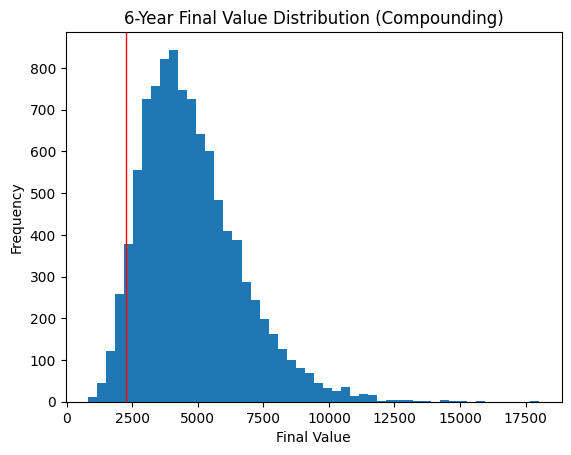

In [12]:
plt.figure()
plt.hist(P6_normal, bins=50)
plt.axvline(P0, linewidth=1, color='red')
plt.title("6-Year Final Value Distribution (Compounding)")
plt.xlabel("Final Value")
plt.ylabel("Frequency")
plt.show()

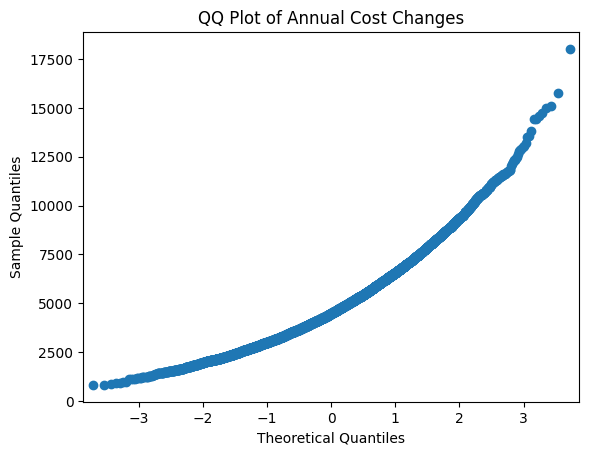

Test Statistic: 0.9507229637199291
p-value: 2.035879993687595e-49


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [13]:
#test for normality
sm.qqplot(P6_normal)
plt.title("QQ Plot of Annual Cost Changes")
plt.show()

stat, p = shapiro(P6_normal)

print("Test Statistic:", stat)
print("p-value:", p)

<h4>Kernel Density Estimation</h4>

In [14]:
bandwidth = 0.07
years = 6
n_sims = 10_000

kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
kde.fit(data['Change'].to_numpy().reshape(-1, 1))

sim_returns = kde.sample(n_sims * years, random_state=SEED).reshape(n_sims, years)

P6_kde = P0 * np.prod(1 + sim_returns, axis=1)

In [15]:
summarize_sim(P6_kde, initial_value=P0)

,Initial Value,Mean Final Value,Median Final Value,Prob(Lose Money),55% Return Level,95% Return Level
0,2279.8,4831.27073,4498.608962,0.0644,1.084401,2.807419


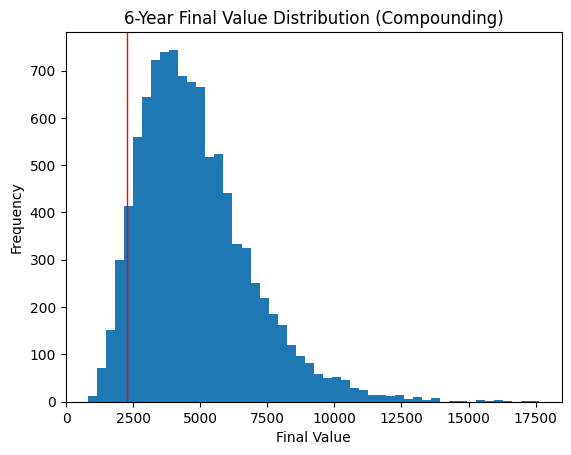

In [16]:
plt.figure()
plt.hist(P6_kde, bins=50)
plt.axvline(P0, linewidth=1, color='red')
plt.title("6-Year Final Value Distribution (Compounding)")
plt.xlabel("Final Value")
plt.ylabel("Frequency")
plt.show()

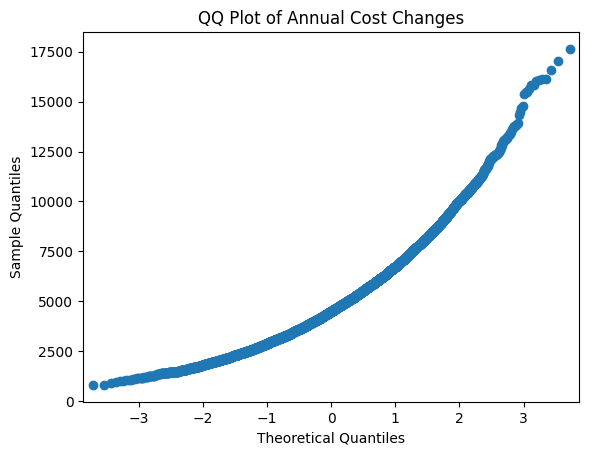

Test Statistic: 0.9384521427842222
p-value: 2.5496419138751907e-53


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [17]:
#test for normality
sm.qqplot(P6_kde)
plt.title("QQ Plot of Annual Cost Changes")
plt.show()

stat, p = shapiro(P6_kde)

print("Test Statistic:", stat)
print("p-value:", p)

<h2>Simulate Additional Years</h2>

In [18]:
#2012 - 2015
sim_12_15 = rng.uniform(-0.22, -0.07, size=(n_sims, 3))

#2015 - 2024
sim_15_24 = rng.uniform(0.02, 0.06, size=(n_sims, 9))

#2025
sim_25 = rng.uniform(0.02, 0.06, size=(n_sims, 1))

#concatenate these into an array
future_changes = np.concatenate([sim_12_15, sim_15_24, sim_25], axis=1)

<h2>Apply Additional Years to Simulations Through 2012</h2>

In [19]:
P2025_normal = P6_normal * np.prod(1 + future_changes, axis=1)

In [20]:
P2025_kde = P6_kde * np.prod(1 + future_changes, axis=1)

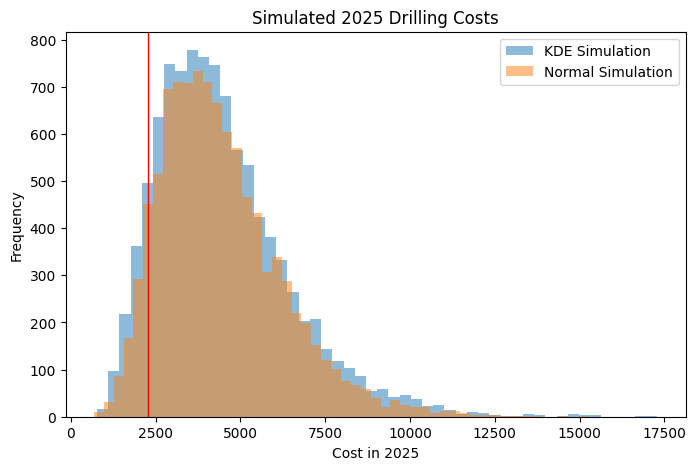

In [21]:
plt.figure(figsize=(8,5))

plt.hist(P2025_kde, bins=50, alpha=0.5, label="KDE Simulation")
plt.hist(P2025_normal, bins=50, alpha=0.5, label="Normal Simulation")
plt.axvline(P0, linewidth=1, color='red')

plt.title("Simulated 2025 Drilling Costs")
plt.xlabel("Cost in 2025")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [22]:
summarize_sim(P2025_normal, initial_value=P0)

,Initial Value,Mean Final Value,Median Final Value,Prob(Lose Money),55% Return Level,95% Return Level
0,2279.8,4417.456653,4133.782913,0.0785,0.901979,2.390479


In [23]:
summarize_sim(P2025_kde, initial_value=P0)

,Initial Value,Mean Final Value,Median Final Value,Prob(Lose Money),55% Return Level,95% Return Level
0,2279.8,4473.026877,4144.568974,0.0939,0.913247,2.585143
